In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler


file_path = r"/content/drive/MyDrive/Sent_Analytical-data-final_01082024.csv"
df = pd.read_csv(file_path)

total_rows = len(df)
null_counts = df.isnull().sum()
null_percentage = (null_counts / total_rows) * 100


columns_to_drop = null_percentage[null_percentage > 50].index
df = df.drop(columns=columns_to_drop)

print("Dropped columns:", columns_to_drop.tolist())
print("Remaining columns:", df.columns.tolist())


trace_elements = ['Co (ppm)', 'Ni   (ppm)', 'Cu (ppm)', 'Zn   (ppm)', 'As  (ppm)', 'Se   (ppm)',
                   'Ag (ppm)', 'Sb   (ppm)', 'Te (ppm)', 'Au (ppm)', 'Pb   (ppm)',
                  'Bi   (ppm)',]


for col in trace_elements:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].replace(0, 1e-6)


df_log = df.copy()
df_log[trace_elements] = df_log[trace_elements].applymap(lambda x: np.log(x) if pd.notnull(x) else np.nan)


scaler = MinMaxScaler()
df_scaled = df_log.copy()
df_scaled[trace_elements] = pd.DataFrame(
    scaler.fit_transform(df_log[trace_elements]),
    columns=trace_elements,
    index=df_log.index
)

df_scaled['Deposit type'] = df['Deposit type']


print(f"Preprocessing completed. Shape: {df_scaled.shape}")
df_scaled

Dropped columns: ['Mo (ppm)', 'Tl   (ppm)', 'Mn (ppm)', 'V    (ppm)']
Remaining columns: ['Co (ppm)', 'Ni   (ppm)', 'Cu (ppm)', 'Zn   (ppm)', 'As  (ppm)', 'Se   (ppm)', 'Ag (ppm)', 'Sb   (ppm)', 'Te (ppm)', 'Au (ppm)', 'Pb   (ppm)', 'Bi   (ppm)', 'Deposit type']
Preprocessing completed. Shape: (5102, 13)


/tmp/ipykernel_9076/3688804552.py:32: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,Co (ppm),Ni (ppm),Cu (ppm),Zn (ppm),As (ppm),Se (ppm),Ag (ppm),Sb (ppm),Te (ppm),Au (ppm),Pb (ppm),Bi (ppm),Deposit type
0,0.782067,0.769544,0.713110,0.726457,0.718480,0.728035,0.284766,0.800890,0.579844,0.531373,0.680231,0.485482,Orogenic type gold deposit
1,0.744505,0.733204,0.637366,0.696558,0.795319,0.719566,0.327553,0.827256,0.601431,0.531373,0.646547,0.501609,Orogenic type gold deposit
2,0.747687,0.739958,0.665949,0.728868,0.808188,0.718223,0.342160,0.816684,NaN,0.541295,0.730277,0.501609,Orogenic type gold deposit
3,0.769017,0.765588,0.579280,0.690980,0.719333,0.719566,0.348494,0.816594,NaN,0.555813,0.742496,0.513051,Orogenic type gold deposit
4,0.790669,0.789385,0.713384,0.643347,0.825304,0.709260,0.309259,0.797897,NaN,0.541295,0.705215,0.485482,Orogenic type gold deposit
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5097,0.962597,0.847755,0.602031,0.641860,0.922538,0.693875,0.332251,0.606837,0.686848,0.545455,0.726653,0.719595,Intrusion related gold deposit
5098,0.841874,0.855578,0.609662,0.617718,0.872795,0.687575,0.369435,0.636561,0.637047,0.561463,0.628523,0.701776,Intrusion related gold deposit
5099,0.933911,0.708075,0.641454,0.615840,0.886934,0.695218,0.401922,0.639097,0.690084,0.600187,0.722560,0.754000,Intrusion related gold deposit
5100,0.898885,0.752018,0.569055,0.600884,0.865321,0.699438,0.301590,0.565148,0.562250,0.504006,0.682354,0.651514,Intrusion related gold deposit


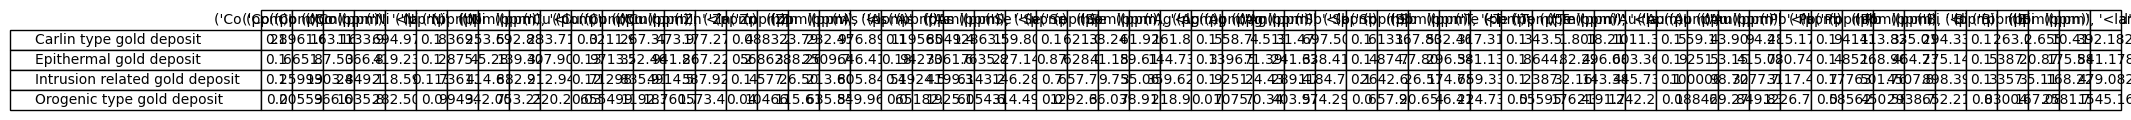

In [28]:

summary_stats = df.groupby('Deposit type').agg(
    {element: ['min', 'max', 'mean', 'std', lambda x: x.std() / x.mean() * 100] for element in df.columns if element != 'Deposit type'}
)

import pandas as pd
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(20, len(summary_stats) * 0.25))
ax.axis('off')

table = pd.plotting.table(ax, summary_stats.round(3), loc='center', cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.show()
plt.savefig('summary_statistics.png', bbox_inches='tight', dpi=300)
plt.close()


📊 Imputation Performance Summary:


,Avg KS Distance,Avg Chi2 Distance,Correlation Deviation
MICE,0.1501,323.1519,0.0773
KNN,0.2764,456.5709,0.0841
Mean,0.5409,3164.5707,0.0801


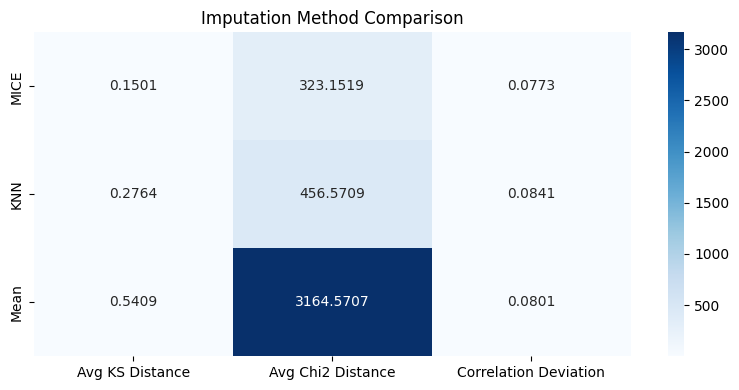

In [29]:
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy.stats import ks_2samp, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns


missing_mask = df_scaled[trace_elements].isna()

# --- 3 Imputation Methods ---

def impute_all_methods(df_scaled, trace_elements):
    datasets = {}

    # KNN Imputation
    knn_imputer = KNNImputer(n_neighbors=5)
    df_knn = df_scaled.copy()
    df_knn[trace_elements] = knn_imputer.fit_transform(df_knn[trace_elements])
    datasets['KNN'] = df_knn

    # MICE Imputation
    mice_imputer = IterativeImputer(random_state=0, sample_posterior=True)
    df_mice = df_scaled.copy()
    df_mice[trace_elements] = mice_imputer.fit_transform(df_mice[trace_elements])
    datasets['MICE'] = df_mice

    # Mean Imputation
    mean_imputer = SimpleImputer(strategy='mean')
    df_mean = df_scaled.copy()
    df_mean[trace_elements] = mean_imputer.fit_transform(df_mean[trace_elements])
    datasets['Mean'] = df_mean

    return datasets

imputed_datasets = impute_all_methods(df_scaled, trace_elements)


def evaluate_imputation(imputed_df, original_df, mask, trace_elements):
    ks_scores = {}
    chi2_scores = {}
    for col in trace_elements:
        imputed_vals = imputed_df.loc[mask[col], col]
        observed_vals = original_df.loc[~mask[col], col]


        ks_stat = ks_2samp(imputed_vals, observed_vals).statistic
        ks_scores[col] = ks_stat


        bins = np.histogram_bin_edges(observed_vals.dropna(), bins='auto')
        obs_hist, _ = np.histogram(observed_vals.dropna(), bins=bins)
        imp_hist, _ = np.histogram(imputed_vals.dropna(), bins=bins)
        chi2 = chi2_contingency([obs_hist + 1, imp_hist + 1])[0]
        chi2_scores[col] = chi2

    return ks_scores, chi2_scores

def correlation_diff(original_df, imputed_df, trace_elements):
    corr_orig = original_df[trace_elements].corr()
    corr_imp = imputed_df[trace_elements].corr()
    diff = np.abs(corr_orig - corr_imp)
    return diff.mean().mean()

summary = {}

for method, df_imp in imputed_datasets.items():
    ks, chi2 = evaluate_imputation(df_imp, df_scaled, missing_mask, trace_elements)
    ks_avg = np.mean(list(ks.values()))
    chi2_avg = np.mean(list(chi2.values()))
    corr_dev = correlation_diff(df_scaled.dropna(), df_imp, trace_elements)

    summary[method] = {
        "Avg KS Distance": round(ks_avg, 4),
        "Avg Chi2 Distance": round(chi2_avg, 4),
        "Correlation Deviation": round(corr_dev, 4)
    }


summary_df = pd.DataFrame(summary).T.sort_values(by="Avg KS Distance")
print("📊 Imputation Performance Summary:")
display(summary_df)


plt.figure(figsize=(8, 4))
sns.heatmap(summary_df, annot=True, cmap="Blues", fmt=".4f")
plt.title("Imputation Method Comparison")
plt.tight_layout()
plt.show()


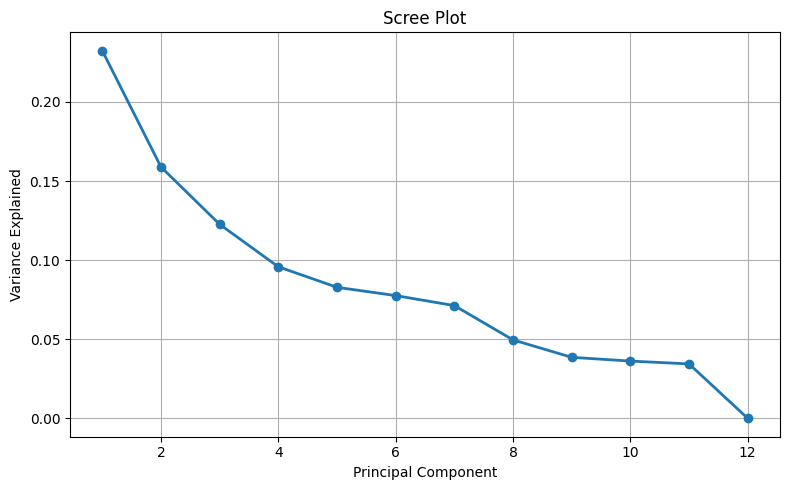

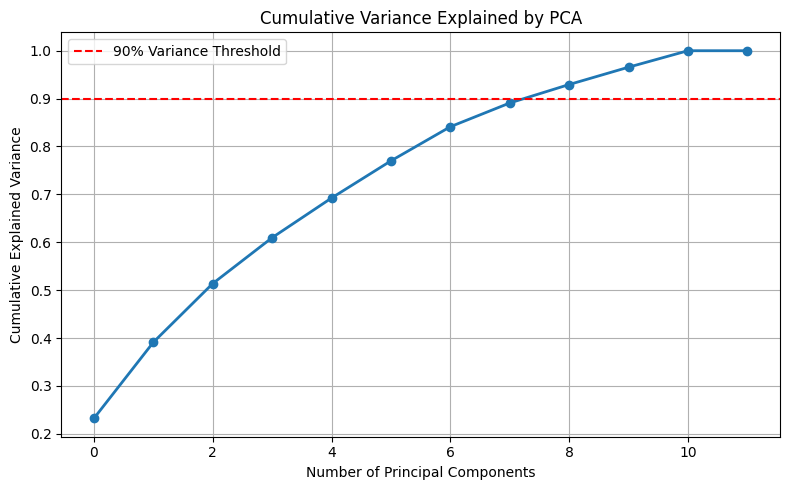

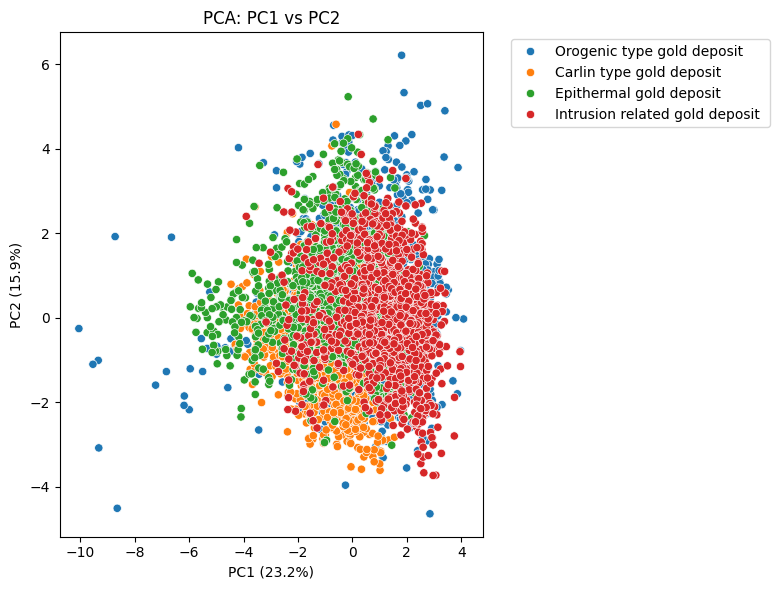

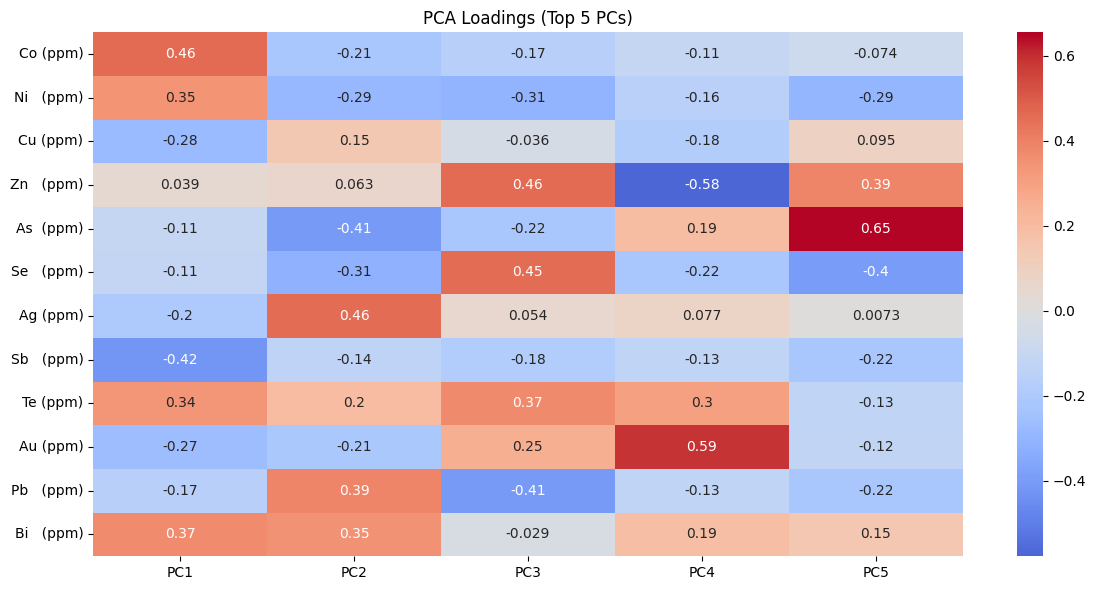

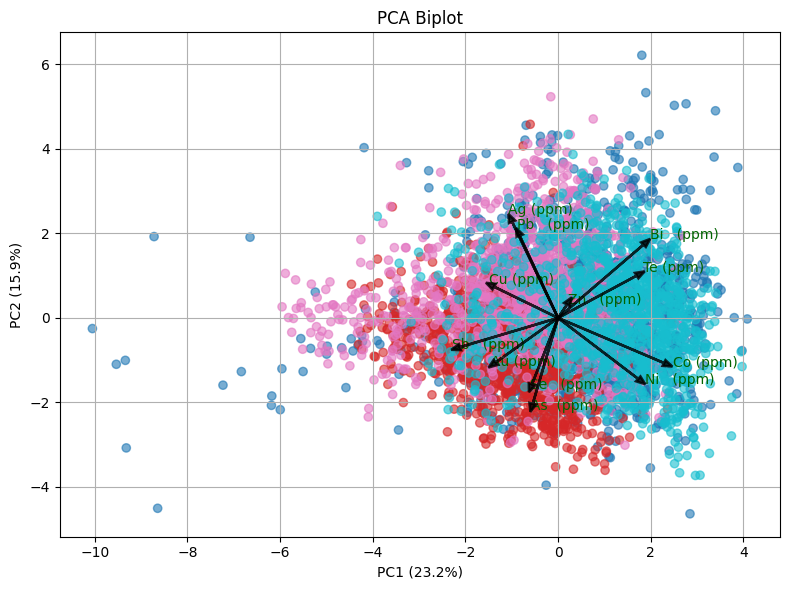

Explained Variance Ratio for each PC:
PC1: 0.2323 (23.23%)
PC2: 0.1589 (15.89%)
PC3: 0.1226 (12.26%)
PC4: 0.0958 (9.58%)
PC5: 0.0828 (8.28%)
PC6: 0.0776 (7.76%)
PC7: 0.0713 (7.13%)
PC8: 0.0496 (4.96%)
PC9: 0.0386 (3.86%)
PC10: 0.0362 (3.62%)
PC11: 0.0344 (3.44%)
PC12: 0.0000 (0.00%)

Explained Variance (Eigenvalues) for each PC:
PC1: 2.7887
PC2: 1.9067
PC3: 1.4717
PC4: 1.1496
PC5: 0.9940
PC6: 0.9312
PC7: 0.8553
PC8: 0.5950
PC9: 0.4629
PC10: 0.4344
PC11: 0.4129
PC12: 0.0000

Cumulative Variance Explained:
First 1 PCs: 0.2323 (23.23%)
First 2 PCs: 0.3912 (39.12%)
First 3 PCs: 0.5138 (51.38%)
First 4 PCs: 0.6096 (60.96%)
First 5 PCs: 0.6924 (69.24%)
First 6 PCs: 0.7700 (77.00%)
First 7 PCs: 0.8413 (84.13%)
First 8 PCs: 0.8908 (89.08%)
First 9 PCs: 0.9294 (92.94%)
First 10 PCs: 0.9656 (96.56%)
First 11 PCs: 1.0000 (100.00%)
First 12 PCs: 1.0000 (100.00%)


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


df_clr = imputed_datasets['KNN'].copy()
log_values = df_clr[trace_elements]


clr_transformed = log_values.subtract(log_values.mean(axis=1), axis=0)


clr_transformed['Deposit type'] = df['Deposit type']


features = [col for col in clr_transformed.columns if col != 'Deposit type']
X = clr_transformed[features]
y = clr_transformed['Deposit type']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_, 'o-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'o-', linewidth=2)
plt.title('Cumulative Variance Explained by PCA')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance Threshold')
plt.legend()
plt.tight_layout()
plt.show()


pca_df = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['Deposit type'] = y

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Deposit type', palette='tab10')
plt.title('PCA: PC1 vs PC2')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(features))],
                        index=features)

plt.figure(figsize=(12, 6))
sns.heatmap(loadings.iloc[:, :5], annot=True, cmap='coolwarm', center=0)
plt.title('PCA Loadings (Top 5 PCs)')
plt.tight_layout()
plt.show()


def biplot(score, coeff, labels=None):
    xs = score[:, 0]
    ys = score[:, 1]
    plt.figure(figsize=(8, 6))
    plt.scatter(xs, ys, alpha=0.6, c=pd.factorize(y)[0], cmap='tab10')

    for i in range(coeff.shape[0]):
        plt.arrow(0, 0,
                  coeff[i, 0]*5, coeff[i, 1]*5,
                  color='black',
                  alpha=0.8,
                  head_width=0.15,
                  head_length=0.2,
                  linewidth=1.8,
                  zorder=5)
        if labels is None:
            plt.text(coeff[i, 0]*5.4, coeff[i, 1]*5.4, f"Var{i+1}", color='darkgreen', fontsize=10)
        else:
            plt.text(coeff[i, 0]*5.4, coeff[i, 1]*5.4, labels[i], color='darkgreen', fontsize=10)

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.grid(True)
    plt.title('PCA Biplot')
    plt.tight_layout()
    plt.show()


biplot(X_pca, pca.components_.T[:, :2], labels=df.columns.tolist())


explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio for each PC:")
for i, var in enumerate(explained_variance_ratio, start=1):
    print(f"PC{i}: {var:.4f} ({var*100:.2f}%)")


explained_variance = pca.explained_variance_
print("\nExplained Variance (Eigenvalues) for each PC:")
for i, val in enumerate(explained_variance, start=1):
    print(f"PC{i}: {val:.4f}")
cumulative_variance = np.cumsum(explained_variance_ratio)
print("\nCumulative Variance Explained:")
for i, cum_var in enumerate(cumulative_variance, start=1):
    print(f"First {i} PCs: {cum_var:.4f} ({cum_var*100:.2f}%)")


In [31]:
import pandas as pd
import plotly.express as px



melted_data = df.melt(id_vars='Deposit type', var_name='Element', value_name='Concentration')

# Box Plot

fig = px.box(
    melted_data,
    x='Element',
    y='Concentration',
    color='Deposit type',
    points=False,
    title='Box Plot of Element Concentrations by Deposit Type'
)


fig.update_layout(
    yaxis_title='Concentration (ppm)',
    xaxis_title='Element',
    yaxis_type='log',
    width=1000,
    height=700,
    legend_title='Deposit Type',
    legend=dict(
        orientation='v',
        x=1,
        y=1,
        xanchor='left',
        yanchor='top'
    )
)


fig.show()


In [32]:
import pandas as pd
import plotly.express as px
from ipywidgets import interact
import scipy.stats as stats
import matplotlib.pyplot as plt

def scatter_plot(x_axis, y_axis, log_x=False, log_y=False):

    fig = px.scatter(
        df, x=x_axis, y=y_axis, color='Deposit type',
        title=f'Scatter plot of {x_axis} vs {y_axis}',
        labels={x_axis: x_axis, y_axis: y_axis}
    )
    fig.update_layout(
        xaxis_type='log' if log_x else 'linear',
        yaxis_type='log' if log_y else 'linear',
        width=700,
        height=500
    )
    file_name = f'scatter_plot_{x_axis}_vs_{y_axis}.html'
    fig.write_html(file_name)

    fig.show()
columns = df.columns.tolist()
interact(scatter_plot, x_axis=columns, y_axis=columns, log_x=True, log_y=True)

scatter_plot


interactive(children=(Dropdown(description='x_axis', options=('Co (ppm)', 'Ni   (ppm)', 'Cu (ppm)', 'Zn   (ppm…

<function __main__.scatter_plot(x_axis, y_axis, log_x=False, log_y=False)>

 KNN Imputation Results

 Model: Random Forest
Accuracy: 0.8032

 Classification Report:
                                 precision    recall  f1-score   support

      Carlin type gold deposit       0.824     0.851     0.837       242
       Epithermal gold deposit       0.720     0.698     0.709       232
Intrusion related gold deposit       0.899     0.810     0.852       221
    Orogenic type gold deposit       0.786     0.839     0.812       316

                       accuracy                          0.803      1011
                      macro avg      0.807     0.800     0.803      1011
                   weighted avg      0.805     0.803     0.803      1011



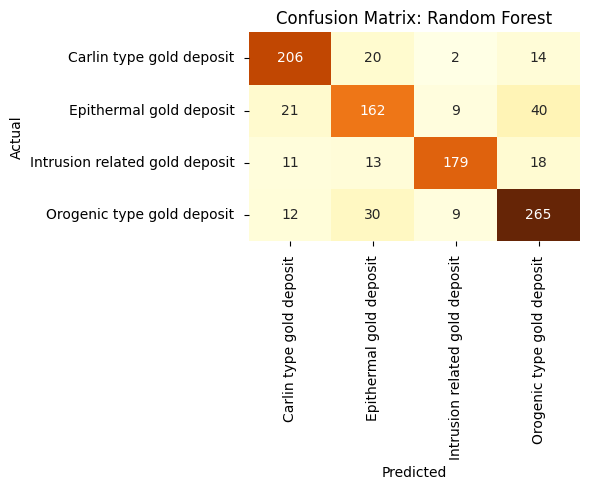


 Model: Gradient Boosting
Accuracy: 0.7923

 Classification Report:
                                 precision    recall  f1-score   support

      Carlin type gold deposit       0.828     0.835     0.831       242
       Epithermal gold deposit       0.692     0.737     0.714       232
Intrusion related gold deposit       0.845     0.792     0.818       221
    Orogenic type gold deposit       0.808     0.801     0.804       316

                       accuracy                          0.792      1011
                      macro avg      0.793     0.791     0.792      1011
                   weighted avg      0.794     0.792     0.793      1011



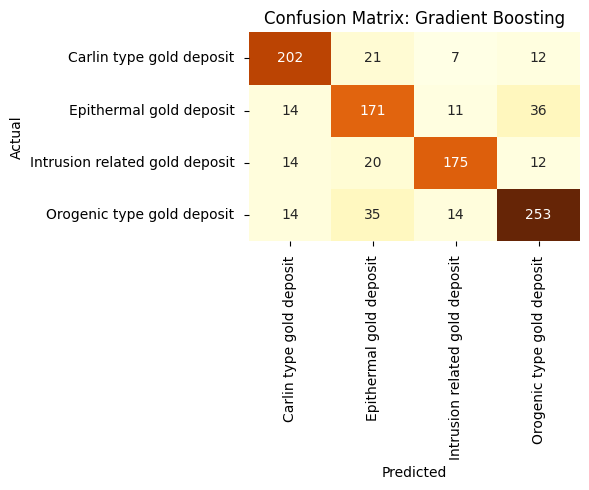


 Model: Bagging
Accuracy: 0.7745

 Classification Report:
                                 precision    recall  f1-score   support

      Carlin type gold deposit       0.819     0.822     0.821       242
       Epithermal gold deposit       0.671     0.703     0.686       232
Intrusion related gold deposit       0.871     0.765     0.814       221
    Orogenic type gold deposit       0.761     0.797     0.779       316

                       accuracy                          0.774      1011
                      macro avg      0.781     0.772     0.775      1011
                   weighted avg      0.778     0.774     0.775      1011



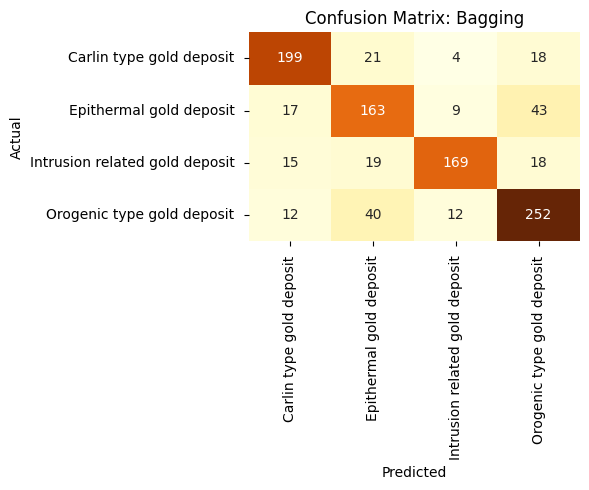


 Model: SVM
Accuracy: 0.7488

 Classification Report:
                                 precision    recall  f1-score   support

      Carlin type gold deposit       0.754     0.810     0.781       242
       Epithermal gold deposit       0.682     0.629     0.655       232
Intrusion related gold deposit       0.872     0.742     0.802       221
    Orogenic type gold deposit       0.719     0.794     0.755       316

                       accuracy                          0.749      1011
                      macro avg      0.757     0.744     0.748      1011
                   weighted avg      0.752     0.749     0.748      1011



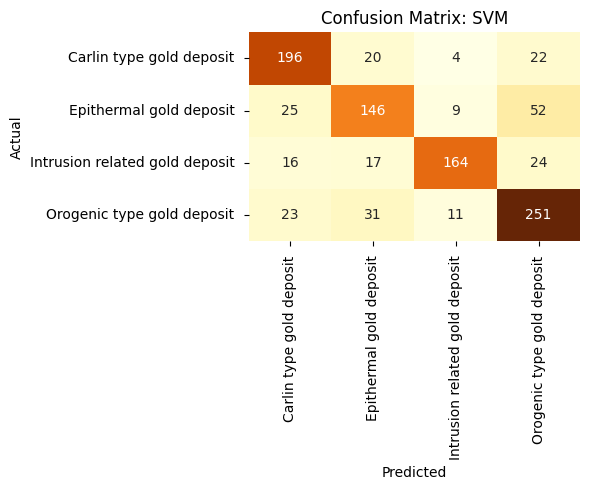


 Model: Stacking
Accuracy: 0.8051

 Classification Report:
                                 precision    recall  f1-score   support

      Carlin type gold deposit       0.824     0.851     0.837       242
       Epithermal gold deposit       0.738     0.703     0.720       232
Intrusion related gold deposit       0.867     0.828     0.847       221
    Orogenic type gold deposit       0.796     0.829     0.812       316

                       accuracy                          0.805      1011
                      macro avg      0.806     0.803     0.804      1011
                   weighted avg      0.805     0.805     0.805      1011



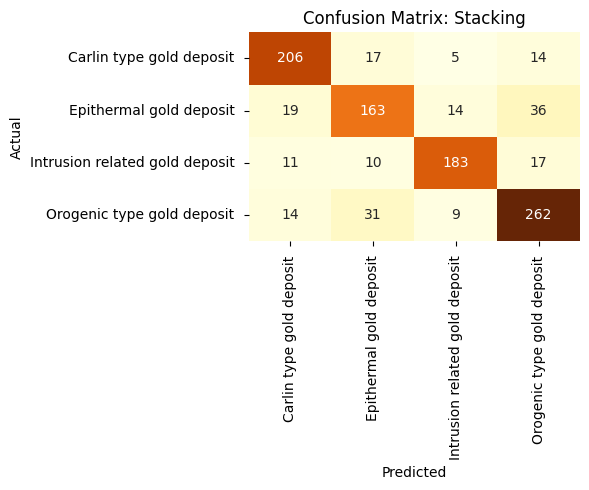


 Accuracy Comparison for KNN Imputation:


/tmp/ipykernel_9076/2134013469.py:74: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




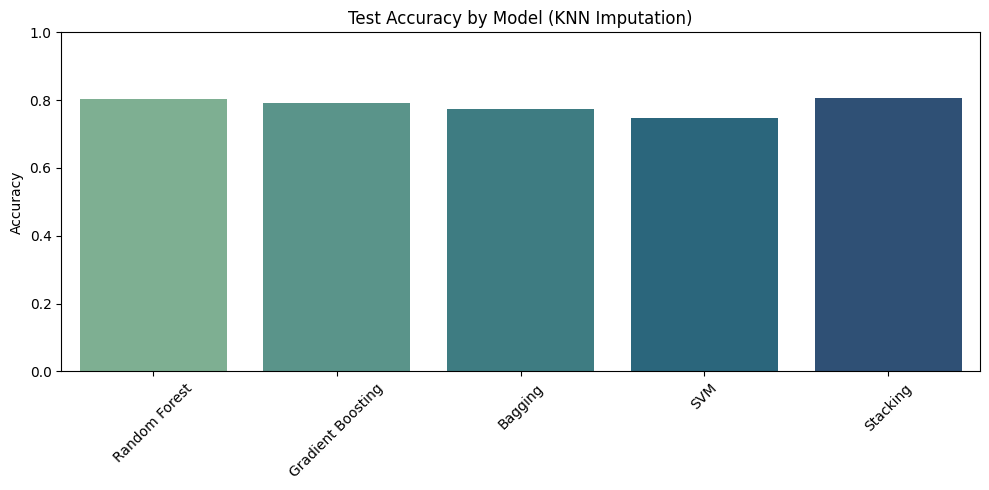


 MICE Imputation Results

 Model: Random Forest
Accuracy: 0.7794

 Classification Report:
                                 precision    recall  f1-score   support

      Carlin type gold deposit       0.784     0.839     0.810       242
       Epithermal gold deposit       0.709     0.703     0.706       232
Intrusion related gold deposit       0.868     0.747     0.803       221
    Orogenic type gold deposit       0.774     0.813     0.793       316

                       accuracy                          0.779      1011
                      macro avg      0.784     0.775     0.778      1011
                   weighted avg      0.782     0.779     0.779      1011



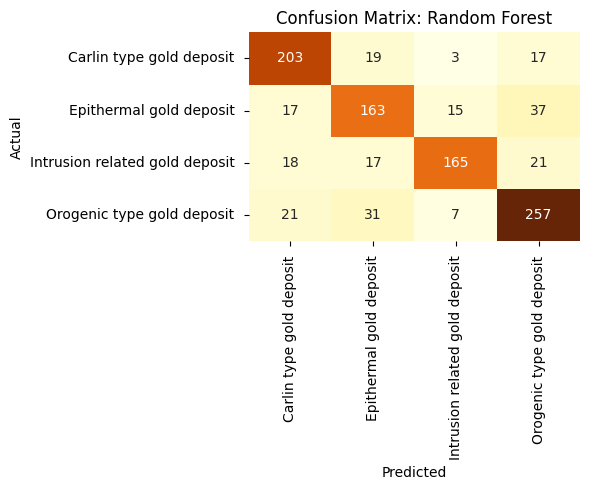


 Model: Gradient Boosting
Accuracy: 0.7616

 Classification Report:
                                 precision    recall  f1-score   support

      Carlin type gold deposit       0.778     0.798     0.788       242
       Epithermal gold deposit       0.678     0.698     0.688       232
Intrusion related gold deposit       0.835     0.756     0.793       221
    Orogenic type gold deposit       0.765     0.785     0.775       316

                       accuracy                          0.762      1011
                      macro avg      0.764     0.759     0.761      1011
                   weighted avg      0.764     0.762     0.762      1011



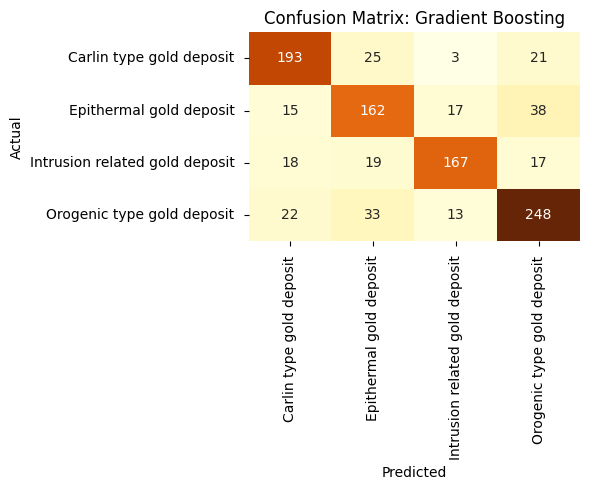


 Model: Bagging
Accuracy: 0.7498

 Classification Report:
                                 precision    recall  f1-score   support

      Carlin type gold deposit       0.785     0.769     0.777       242
       Epithermal gold deposit       0.653     0.672     0.662       232
Intrusion related gold deposit       0.833     0.747     0.788       221
    Orogenic type gold deposit       0.745     0.794     0.769       316

                       accuracy                          0.750      1011
                      macro avg      0.754     0.745     0.749      1011
                   weighted avg      0.753     0.750     0.750      1011



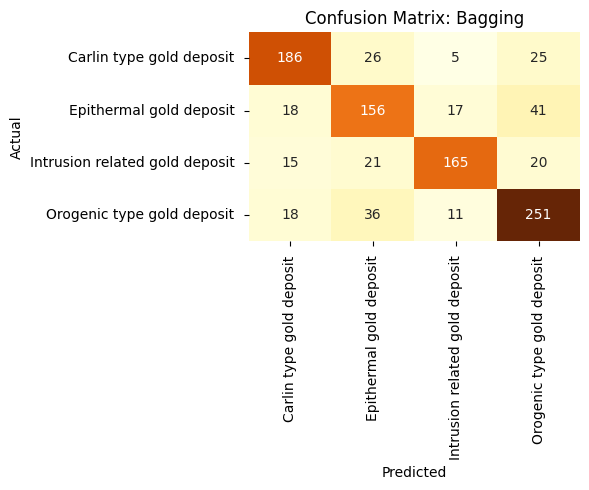


 Model: SVM
Accuracy: 0.7082

 Classification Report:
                                 precision    recall  f1-score   support

      Carlin type gold deposit       0.745     0.785     0.765       242
       Epithermal gold deposit       0.635     0.608     0.621       232
Intrusion related gold deposit       0.788     0.656     0.716       221
    Orogenic type gold deposit       0.686     0.759     0.721       316

                       accuracy                          0.708      1011
                      macro avg      0.713     0.702     0.706      1011
                   weighted avg      0.711     0.708     0.707      1011



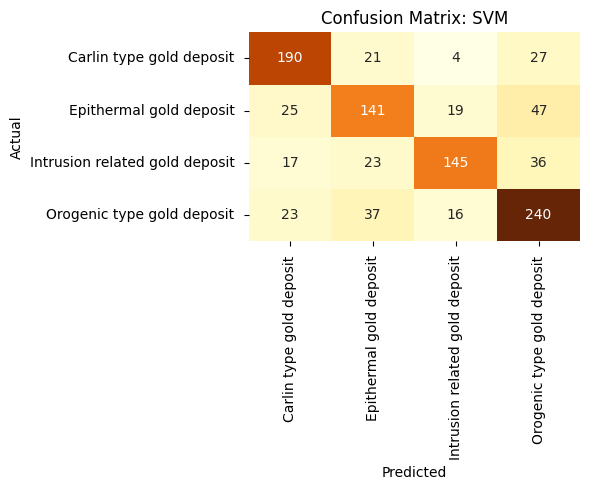


 Model: Stacking
Accuracy: 0.7735

 Classification Report:
                                 precision    recall  f1-score   support

      Carlin type gold deposit       0.811     0.818     0.815       242
       Epithermal gold deposit       0.698     0.698     0.698       232
Intrusion related gold deposit       0.851     0.747     0.795       221
    Orogenic type gold deposit       0.754     0.813     0.782       316

                       accuracy                          0.773      1011
                      macro avg      0.778     0.769     0.773      1011
                   weighted avg      0.776     0.773     0.774      1011



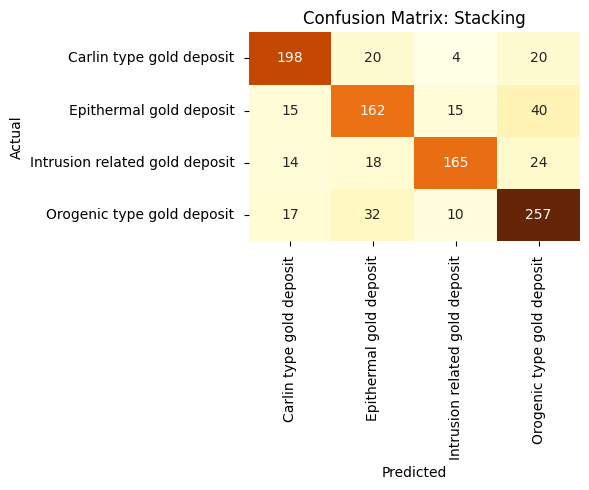


 Accuracy Comparison for MICE Imputation:


/tmp/ipykernel_9076/2134013469.py:74: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




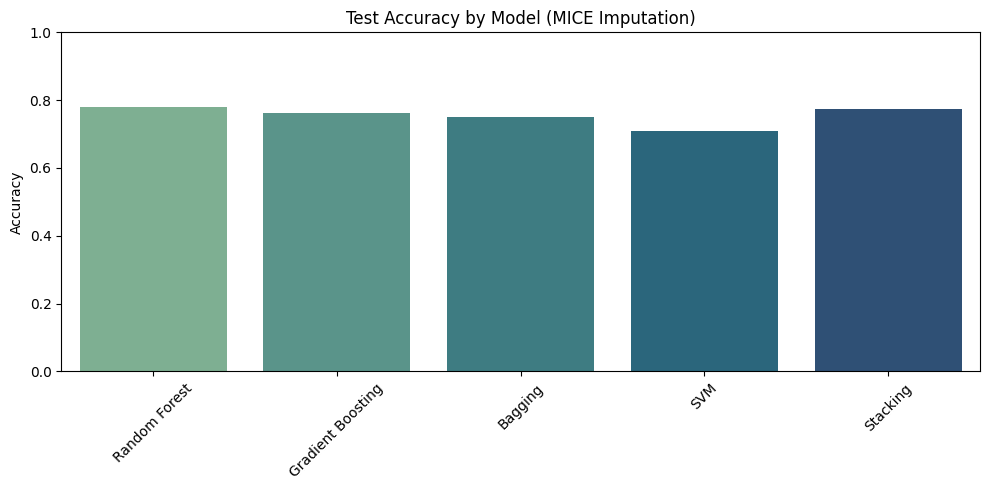

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


def split_data(df, features, label_col):
    X = df[features]
    y = df[label_col]

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.99, stratify=y_temp, random_state=42)

    return X_train, X_val, X_test, y_train, y_val, y_test


def train_and_evaluate(X_train, X_val, X_test, y_train, y_val, y_test, label):
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

    models = {
        'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=300, random_state=42),
        'Bagging': BaggingClassifier(n_estimators=300, random_state=42),
        'SVM': SVC(kernel='rbf', probability=True, random_state=42),
        'Stacking': StackingClassifier(
            estimators=[('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
                        ('svc', SVC(kernel='rbf', probability=True))],
            final_estimator=LogisticRegression(max_iter=1000), passthrough=False)
    }

    results = {}

    for name, model in models.items():
        print(f"\n Model: {name}")
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        report = classification_report(y_test, preds, digits=3)
        cm = confusion_matrix(y_test, preds, labels=np.unique(y_test))


        results[name] = {
            "accuracy": acc,
            "report": report,
            "conf_matrix": cm,
            "model": model
        }


        print(f"Accuracy: {acc:.4f}\n")
        print(" Classification Report:")
        print(report)


        plt.figure(figsize=(6, 5))
        sns.heatmap(pd.DataFrame(cm, index=np.unique(y_test), columns=np.unique(y_test)),
                    annot=True, fmt='d', cmap='YlOrBr', cbar=False)
        plt.title(f"Confusion Matrix: {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()


    print(f"\n Accuracy Comparison for {label} Imputation:")
    accs = {m: results[m]["accuracy"] for m in results}
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=list(accs.keys()), y=list(accs.values()), palette="crest", ax=ax)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Test Accuracy by Model ({label} Imputation)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return results


trace_elements = ['Co (ppm)', 'Ni   (ppm)', 'Cu (ppm)', 'Zn   (ppm)', 'As  (ppm)', 'Se   (ppm)',
                   'Ag (ppm)', 'Sb   (ppm)', 'Te (ppm)', 'Au (ppm)', 'Pb   (ppm)',
                  'Bi   (ppm)']
label_col = 'Deposit type'


print(" KNN Imputation Results")
X_train, X_val, X_test, y_train, y_val, y_test = split_data(imputed_datasets['KNN'], trace_elements, label_col)
knn_results = train_and_evaluate(X_train, X_val, X_test, y_train, y_val, y_test, label="KNN")


print("\n MICE Imputation Results")
X_train, X_val, X_test, y_train, y_val, y_test = split_data(imputed_datasets['MICE'], trace_elements, label_col)
mice_results = train_and_evaluate(X_train, X_val, X_test, y_train, y_val, y_test, label="MICE")
